In [1]:
import random
import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from PIL import Image
import shutil

In [3]:
from google.colab import drive
drive.mount('/content/drive')

shutil.copytree(
    "/content/drive/MyDrive/Tomato_Disease_Detection/dataset_split",
    "/content/dataset_split"
)

Mounted at /content/drive


'/content/dataset_split'

In [59]:
DATASET_DIR = "/content/dataset_split"

# **EDA**

In [60]:
os.listdir(DATASET_DIR)

['val', 'train', 'test']

In [62]:
classes = sorted(os.listdir(DATASET_DIR))

print(classes)
print(f"\nNumber of classes: {len(classes)}")

['test', 'train', 'val']

Number of classes: 3


In [21]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(DATASET_DIR, cls)
    class_counts[cls] = len(os.listdir(class_path))

df = pd.DataFrame({
    "Class": class_counts.keys(),
    "Images": class_counts.values()
})

df

,Class,Images
0,Tomato___Bacterial_spot,2127
1,Tomato___Early_blight,1000
2,Tomato___Late_blight,1909
3,Tomato___Leaf_Mold,952
4,Tomato___Septoria_leaf_spot,1774
5,Tomato___Spider_mites Two-spotted_spider_mite,1676
6,Tomato___Target_Spot,1404
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
8,Tomato___Tomato_mosaic_virus,373
9,Tomato___healthy,1603


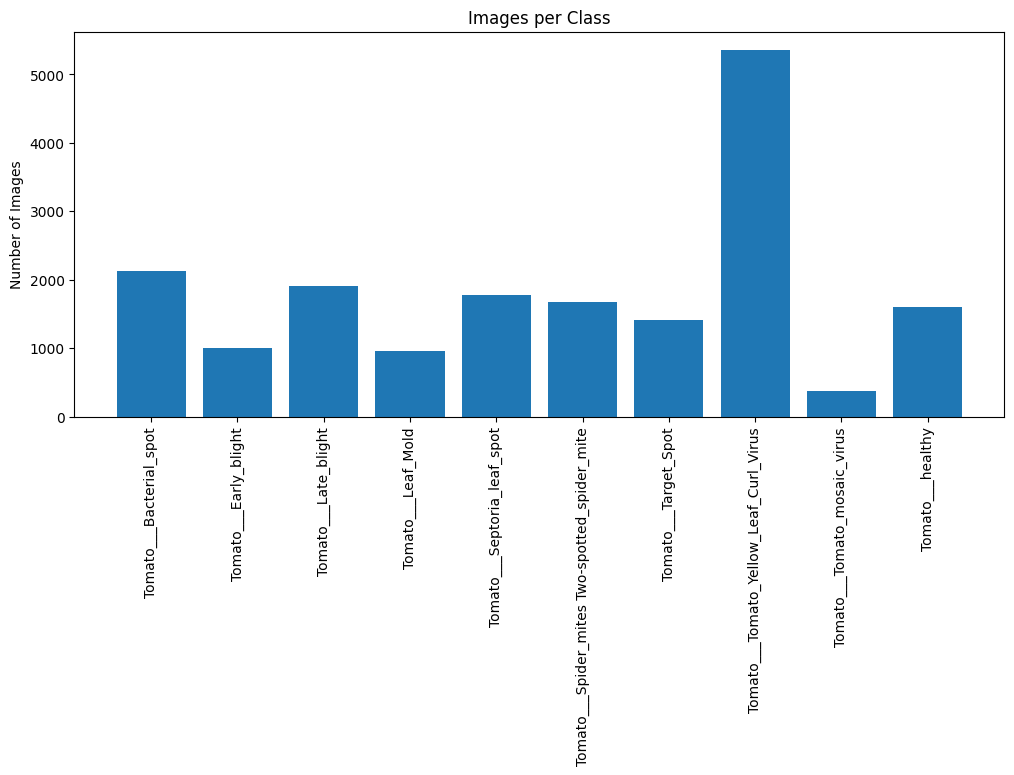

In [22]:
plt.figure(figsize=(12,5))

plt.bar(df["Class"], df["Images"])

plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.title("Images per Class")

plt.show()

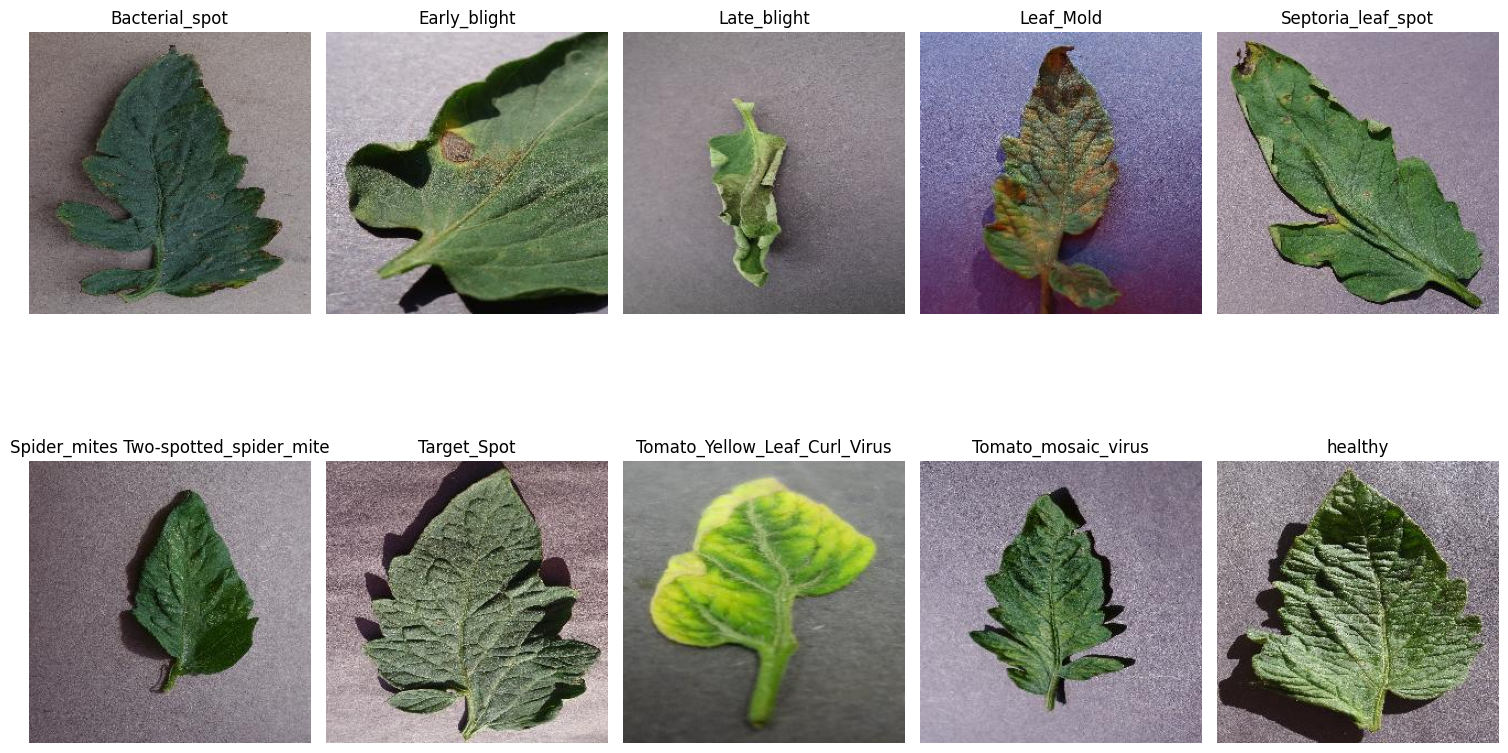

In [10]:
plt.figure(figsize=(15,10))

for i, cls in enumerate(classes):

    class_path = os.path.join(DATASET_DIR, cls)

    image_name = random.choice(os.listdir(class_path))

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2,5,i+1)
    plt.imshow(image)
    plt.title(cls.replace("Tomato___",""))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
sizes = []

for cls in classes:
    class_path = os.path.join(DATASET_DIR, cls)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        image = Image.open(image_path)

        sizes.append(image.size)

In [25]:
unique_sizes = set(sizes)

print(f"Number of unique image sizes: {len(unique_sizes)}")
print(unique_sizes)

Number of unique image sizes: 1
{(256, 256)}


# **Data Pipeline**

In [8]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [29]:
ORIGINAL_DATASET = "/content/drive/MyDrive/Tomato_Disease_Detection/dataset"

SPLIT_DATASET = "/content/dataset_split"

In [12]:
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

random.seed(42)

In [13]:
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(SPLIT_DATASET, split), exist_ok=True)

In [14]:
for split in ["train", "val", "test"]:

    print(f"\n{split.upper()}")

    total_images = 0

    for class_name in os.listdir(os.path.join(SPLIT_DATASET, split)):

        count = len(os.listdir(os.path.join(SPLIT_DATASET, split, class_name)))
        total_images += count

        print(f"{class_name:<45} {count}")

    print(f"\nTotal Images: {total_images}")


TRAIN
Tomato___healthy                              1122
Tomato___Late_blight                          1336
Tomato___Spider_mites Two-spotted_spider_mite 1173
Tomato___Early_blight                         700
Tomato___Tomato_mosaic_virus                  261
Tomato___Leaf_Mold                            666
Tomato___Target_Spot                          982
Tomato___Bacterial_spot                       1488
Tomato___Septoria_leaf_spot                   1241
Tomato___Tomato_Yellow_Leaf_Curl_Virus        3765

Total Images: 12734

VAL
Tomato___healthy                              240
Tomato___Late_blight                          286
Tomato___Spider_mites Two-spotted_spider_mite 251
Tomato___Early_blight                         150
Tomato___Tomato_mosaic_virus                  55
Tomato___Leaf_Mold                            142
Tomato___Target_Spot                          210
Tomato___Bacterial_spot                       319
Tomato___Septoria_leaf_spot                   266
Tomato___Tom

In [15]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DATASET, "train"),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = train_ds.class_names
NUM_CLASSES = len(train_ds.class_names)

print(class_names)
print(NUM_CLASSES)

Found 12734 files belonging to 10 classes.
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
10


In [16]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DATASET, "val"),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2722 files belonging to 10 classes.


In [17]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DATASET, "test"),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2735 files belonging to 10 classes.


In [18]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# **Build the Model**

In [19]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.applications import EfficientNetB0

In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
], name="data_augmentation")

In [21]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

In [22]:
base_model.trainable = False

In [23]:
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

In [24]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [25]:
print("Trainable weights:", len(model.trainable_weights))
print("Non-trainable weights:", len(model.non_trainable_weights))

Trainable weights: 4
Non-trainable weights: 312


# **Compiling and Training Model Head**

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [28]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/Tomato_Disease_Detection/models/best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [30]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [31]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 59s 110ms/step - accuracy: 0.7600 - loss: 0.7183 - val_accuracy: 0.8523 - val_loss: 0.4412 - learning_rate: 0.0010
Epoch 2/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.8547 - loss: 0.4227 - val_accuracy: 0.8648 - val_loss: 0.3602 - learning_rate: 0.0010
Epoch 3/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.8737 - loss: 0.3645 - val_accuracy: 0.8946 - val_loss: 0.2879 - learning_rate: 0.0010
Epoch 4/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.8897 - loss: 0.3280 - val_accuracy: 0.9074 - val_loss: 0.2610 - learning_rate: 0.0010
Epoch 5/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.8941 - loss: 0.3047 - val_accuracy: 0.8817 - val_loss: 0.3161 - learning_rate: 0.0010
Epoch 6/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.8970 - loss: 0.2975 - val_accuracy: 0.9192 - val_loss: 0.2260 - learning_rate: 0.0010
Epoch 7/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.9

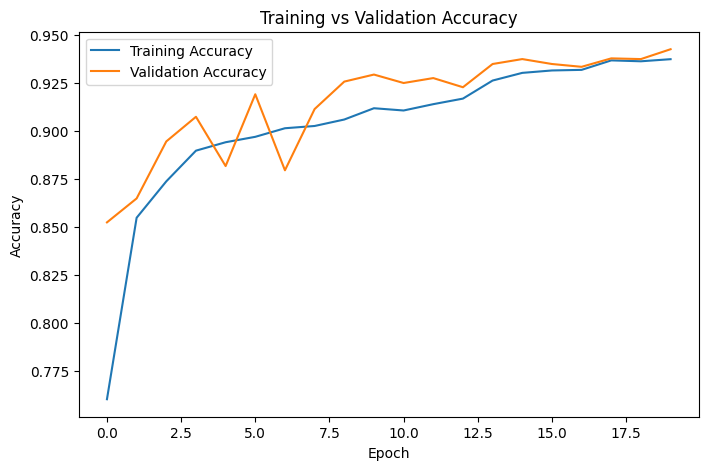

In [32]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

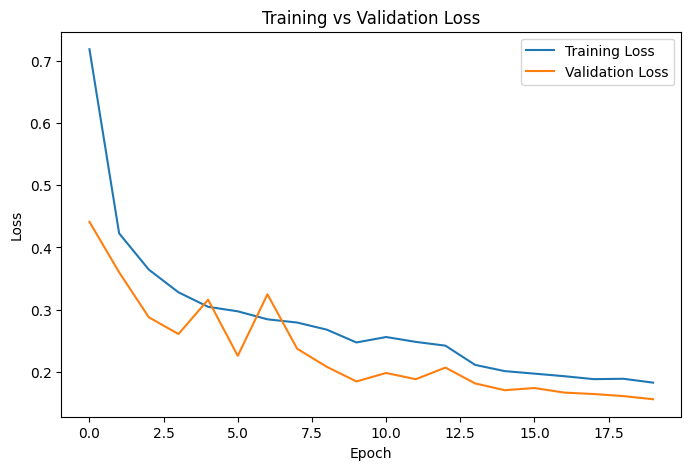

In [63]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [34]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

In [35]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.98      0.97      0.97       320
                        Tomato___Early_blight       0.97      0.83      0.90       150
                         Tomato___Late_blight       0.96      0.95      0.96       287
                           Tomato___Leaf_Mold       0.99      0.92      0.95       144
                  Tomato___Septoria_leaf_spot       0.94      0.94      0.94       267
Tomato___Spider_mites Two-spotted_spider_mite       0.87      0.93      0.90       252
                         Tomato___Target_Spot       0.84      0.90      0.87       212
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      0.99      0.99       805
                 Tomato___Tomato_mosaic_virus       1.00      0.95      0.97        57
                             Tomato___healthy       0.93      0.99      0.96       241

                                     accu

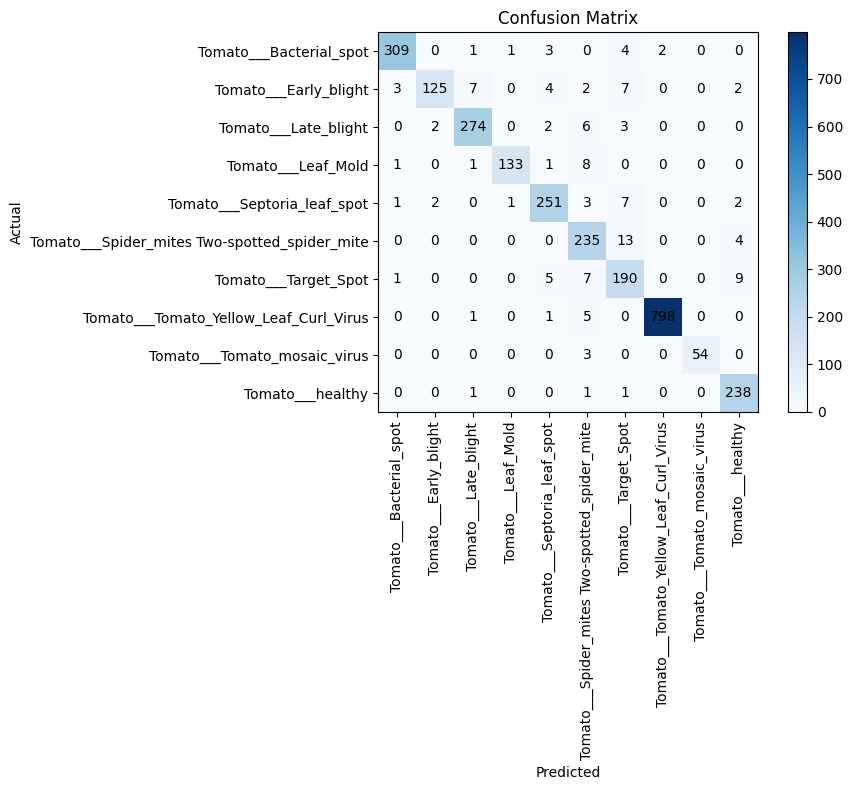

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[309   0   1   1   3   0   4   2   0   0]
 [  3 125   7   0   4   2   7   0   0   2]
 [  0   2 274   0   2   6   3   0   0   0]
 [  1   0   1 133   1   8   0   0   0   0]
 [  1   2   0   1 251   3   7   0   0   2]
 [  0   0   0   0   0 235  13   0   0   4]
 [  1   0   0   0   5   7 190   0   0   9]
 [  0   0   1   0   1   5   0 798   0   0]
 [  0   0   0   0   0   3   0   0  54   0]
 [  0   0   1   0   0   1   1   0   0 238]]


# **Fine Tuning**

In [45]:
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)

0 input_layer False
1 rescaling False
2 normalization False
3 rescaling_1 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze Fals

In [46]:
base_model.trainable = True

In [47]:
fine_tune_at = 222

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [48]:
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [64]:
for i, layer in enumerate(base_model.layers):
    if layer.trainable:
        print(i, layer.name)

222 block7a_expand_conv
224 block7a_expand_activation
225 block7a_dwconv
227 block7a_activation
228 block7a_se_squeeze
229 block7a_se_reshape
230 block7a_se_reduce
231 block7a_se_expand
232 block7a_se_excite
233 block7a_project_conv
235 top_conv
237 top_activation


In [65]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [66]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 63s 116ms/step - accuracy: 0.9422 - loss: 0.1711 - val_accuracy: 0.9386 - val_loss: 0.1627 - learning_rate: 1.0000e-05
Epoch 2/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - accuracy: 0.9427 - loss: 0.1639 - val_accuracy: 0.9442 - val_loss: 0.1425 - learning_rate: 1.0000e-05
Epoch 3/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.9453 - loss: 0.1583 - val_accuracy: 0.9456 - val_loss: 0.1328 - learning_rate: 1.0000e-05
Epoch 4/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 47s 118ms/step - accuracy: 0.9488 - loss: 0.1496 - val_accuracy: 0.9504 - val_loss: 0.1253 - learning_rate: 1.0000e-05
Epoch 5/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 79s 110ms/step - accuracy: 0.9529 - loss: 0.1383 - val_accuracy: 0.9500 - val_loss: 0.1219 - learning_rate: 1.0000e-05
Epoch 6/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 42s 106ms/step - accuracy: 0.9534 - loss: 0.1364 - val_accuracy: 0.9453 - val_loss: 0.1352 - learning_rate: 1.0000e-05
Epoch 7/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 46s 11

In [67]:
val_loss, val_acc = model.evaluate(val_ds)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.9500 - loss: 0.1219
Validation Loss: 0.1219
Validation Accuracy: 0.9500


In [68]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

In [69]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.98      0.95      0.97       319
                        Tomato___Early_blight       0.96      0.75      0.84       150
                         Tomato___Late_blight       0.95      0.98      0.96       286
                           Tomato___Leaf_Mold       0.97      0.92      0.94       142
                  Tomato___Septoria_leaf_spot       0.92      0.94      0.93       266
Tomato___Spider_mites Two-spotted_spider_mite       0.90      0.92      0.91       251
                         Tomato___Target_Spot       0.82      0.91      0.86       210
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      0.99      0.99       803
                 Tomato___Tomato_mosaic_virus       0.98      0.98      0.98        55
                             Tomato___healthy       0.94      0.99      0.97       240

                                     accu

In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[304   1   2   2   6   0   4   0   0   0]
 [  1 113  12   1  10   1   9   0   1   2]
 [  0   0 279   0   0   4   1   0   0   2]
 [  1   0   1 130   2   7   1   0   0   0]
 [  2   4   0   1 251   0   8   0   0   0]
 [  0   0   0   0   0 232  16   1   0   2]
 [  0   0   0   0   3   7 191   0   0   9]
 [  2   0   0   0   0   7   0 794   0   0]
 [  0   0   0   0   0   1   0   0  54   0]
 [  0   0   0   0   0   0   2   0   0 238]]


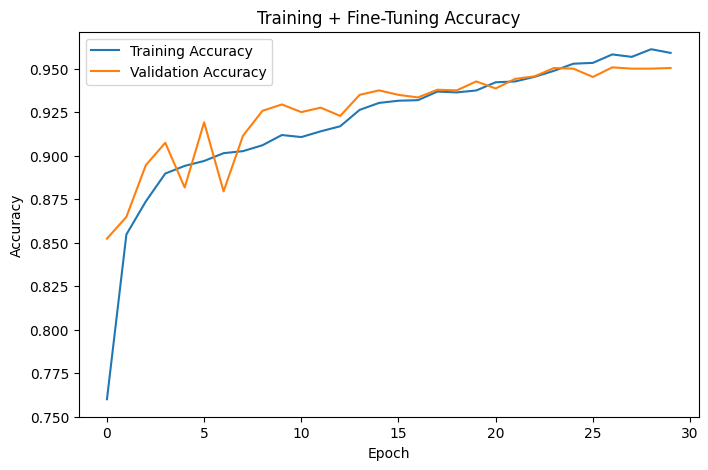

In [71]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"] + fine_tune_history.history["accuracy"]
val_acc = history.history["val_accuracy"] + fine_tune_history.history["val_accuracy"]

plt.figure(figsize=(8,5))
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training + Fine-Tuning Accuracy")
plt.legend()
plt.show()

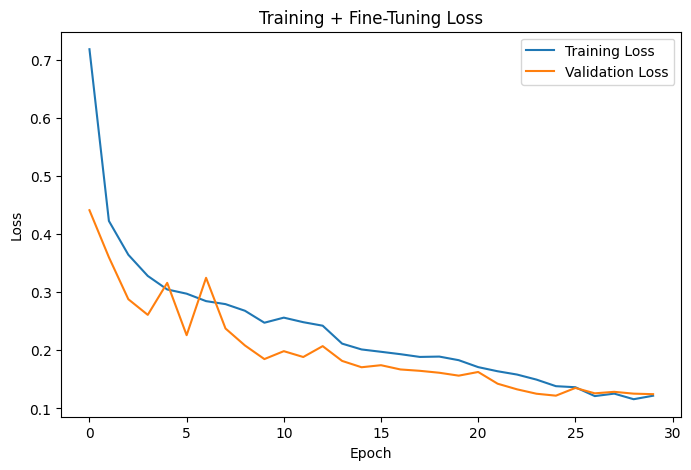

In [72]:
loss = history.history["loss"] + fine_tune_history.history["loss"]
val_loss = history.history["val_loss"] + fine_tune_history.history["val_loss"]

plt.figure(figsize=(8,5))
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training + Fine-Tuning Loss")
plt.legend()
plt.show()